<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Bayesian_Models/Gaussian_Naive_Bayes_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 58 (delta 8), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (58/58), 163.32 MiB | 18.41 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (27/27), done.
Filtering content: 100% (12/12), 851.90 MiB | 27.24 MiB/s, done.
/content/PRMLProject/PRMLProject/PRMLProject/PRMLProject/PRMLProject/PRMLProject


In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle

In [151]:
def unpickle(file):   # Function for unpickling the file
    with open(file, 'rb') as f:
        return pickle.load(f)

# Gaussian Naive Bayes with RAW data

In [152]:
X_train_gnb_raw=unpickle("PreProcessedData/RawPixels_train.pkl")    # Unpickling the training data
print(X_train_gnb_raw.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")     # Unpickling the training labels
print(y_train.shape)
X_test_gnb_raw=unpickle("PreProcessedData/RawPixels_test.pkl")  # Unpickling the testing data
y_test=unpickle("PreProcessedData/Labels_test.pkl")  # Unpickling the testing labels

(50000, 32, 32, 3)
(50000,)


In [153]:
X_train_gnb_raw = X_train_gnb_raw.reshape(50000, -1)   # Flatten the image
X_test_gnb_raw = X_test_gnb_raw.reshape(10000, -1)

print(X_train_gnb_raw.shape)
print(X_test_gnb_raw.shape)

(50000, 3072)
(10000, 3072)


In [154]:
from sklearn.naive_bayes import GaussianNB      # Importing Gaussian Naive Bayes from Scikit Learn
clf = GaussianNB()
clf.fit(X_train_gnb_raw, y_train)    # Fitting on the training data

GaussianNB()

In [155]:
y_pred_raw=clf.predict(X_test_gnb_raw)      # Finding the predicted values
print(y_pred_raw)

[6 8 8 ... 6 5 4]


In [156]:
from sklearn.metrics import accuracy_score          # Finding and printing the accuracy score

accuracy = accuracy_score(y_test, y_pred_raw)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.2976


Text(0.5, 1.0, 'Confusion Matrix')

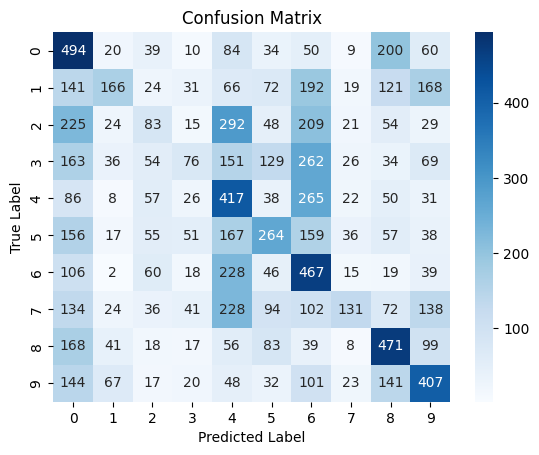

In [157]:
from sklearn.metrics import confusion_matrix           # Ploting the confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_raw)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gaussian Naive Bayes with PCA

In [158]:
X_train_gnb_pca=unpickle("PreProcessedData/TrainFeaturesPCA.pkl")
print(X_train_gnb_pca.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gnb_pca=unpickle("PreProcessedData/TestFeaturesPCA.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 658)
(50000,)


In [159]:
from sklearn.naive_bayes import GaussianNB     # Importing Gaussian Naive Bayes from Scikit Learn
clf = GaussianNB()
clf.fit(X_train_gnb_pca, y_train)

GaussianNB()

In [160]:
y_pred_gnb_pca=clf.predict(X_test_gnb_pca)   # Finding the predicted values
print(y_pred_gnb_pca)

[1 1 8 ... 2 1 3]


In [161]:
from sklearn.metrics import accuracy_score   # Finding and printing the accuracy score

accuracy = accuracy_score(y_test, y_pred_gnb_pca)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.2894


Text(0.5, 1.0, 'Confusion Matrix')

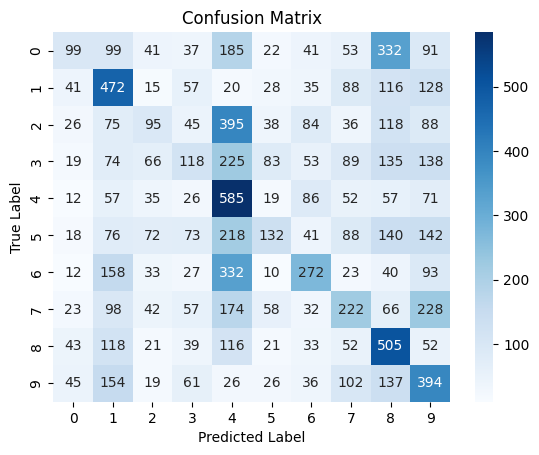

In [162]:
from sklearn.metrics import confusion_matrix      # Ploting the confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_gnb_pca)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gaussian Naive Bayes with HoG

In [163]:
X_train_gnb_hog=unpickle("PreProcessedData/TrainFeaturesHoG.pkl")
print(X_train_gnb_hog.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gnb_hog=unpickle("PreProcessedData/TestFeaturesHoG.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 324)
(50000,)


In [164]:
from sklearn.naive_bayes import GaussianNB  # Importing GNB from SkLearn
clf = GaussianNB()
clf.fit(X_train_gnb_hog, y_train)

GaussianNB()

In [165]:
y_pred_gnb_hog=clf.predict(X_test_gnb_hog)  # Prediction
print(y_pred_gnb_hog)

[6 8 1 ... 5 1 7]


In [166]:
from sklearn.metrics import accuracy_score       # Finding accuracy score

accuracy = accuracy_score(y_test, y_pred_gnb_hog)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4580


Text(0.5, 1.0, 'Confusion Matrix')

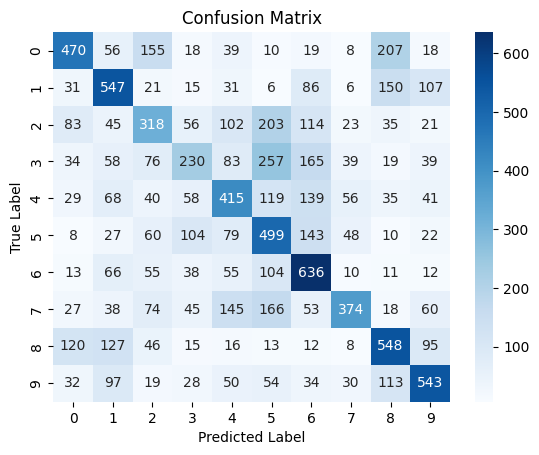

In [167]:
from sklearn.metrics import confusion_matrix     # Plotting confusion matrix
cm = confusion_matrix(y_test, y_pred_gnb_hog)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gaussian Naive Bayes with HoG + PCA

In [168]:
X_train_gnb_hog_pca=unpickle("PreProcessedData/TrainFeaturesHoG_PCA.pkl")
print(X_train_gnb_hog_pca.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gnb_hog_pca=unpickle("PreProcessedData/TestFeaturesHoG_PCA.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 170)
(50000,)


In [169]:
from sklearn.naive_bayes import GaussianNB  # Importing GNB
clf = GaussianNB()
clf.fit(X_train_gnb_hog_pca, y_train)

GaussianNB()

In [170]:
y_pred_gnb_hog_pca=clf.predict(X_test_gnb_hog_pca)   # Predicting values
print(y_pred_gnb_hog_pca)

[5 8 1 ... 2 6 7]


In [171]:
from sklearn.metrics import accuracy_score   # Finding accuracy scores

accuracy = accuracy_score(y_test, y_pred_gnb_hog_pca)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4701


Text(0.5, 1.0, 'Confusion Matrix')

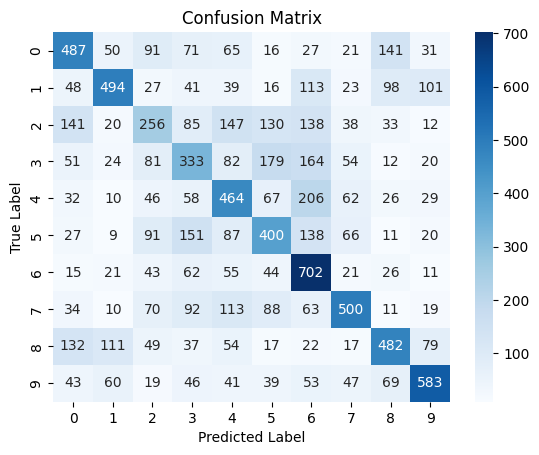

In [172]:
from sklearn.metrics import confusion_matrix     # Plotting confusion matrix
cm = confusion_matrix(y_test, y_pred_gnb_hog_pca)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gaussian Naive Bayes with PCA + HoG

In [173]:
X_train_gnb_pca_hog=unpickle("PreProcessedData/TrainFeaturesPCA_HoG.pkl")
print(X_train_gnb_pca_hog.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gnb_pca_hog=unpickle("PreProcessedData/TestFeaturesPCA_HoG.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 324)
(50000,)


In [174]:
from sklearn.naive_bayes import GaussianNB  # Importing GNB
clf = GaussianNB()
clf.fit(X_train_gnb_pca_hog, y_train)

GaussianNB()

In [175]:
y_pred_gnb_pca_hog=clf.predict(X_test_gnb_pca_hog)   # Predicting values
print(y_pred_gnb_pca_hog)

[5 8 1 ... 5 4 7]


In [176]:
from sklearn.metrics import accuracy_score   # Finding accuracy scores

accuracy = accuracy_score(y_test, y_pred_gnb_pca_hog)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4309


Text(0.5, 1.0, 'Confusion Matrix')

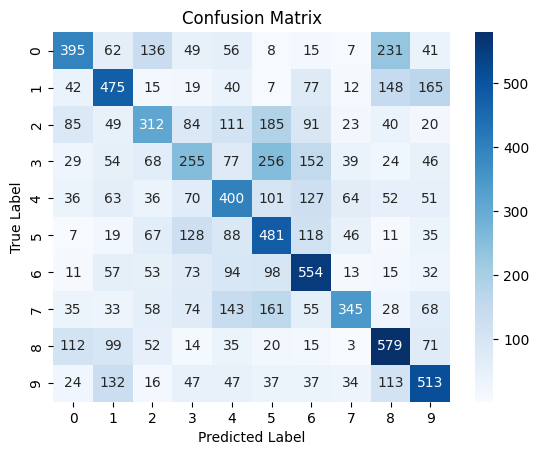

In [177]:
from sklearn.metrics import confusion_matrix     # Plotting confusion matrix
cm = confusion_matrix(y_test, y_pred_gnb_pca_hog)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")